In [ ]:
NAME = "Mihir Das", "Digonta Das", "Hasnain Ashraf"
COLLABORATORS_ID = "22299480","22201633","24241162"

In [ ]:
import numpy as np
import skimage as ski
from skimage import io, color, exposure, img_as_float
import matplotlib.pyplot as plt

# Task 1 - Basic Image Operation

Done by **22299480**

In [ ]:
### BEGIN SOLUTION
I = io.imread('sample.jpeg')
H = I.shape[0] # should contain height
W = I.shape[1] # should contain width
print("Height is", H)
print("Width is", W)
### END SOLUTION

Height is 2048
Width is 1152


0.0 1.0


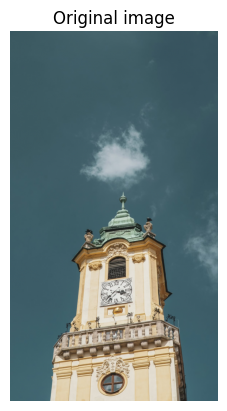

In [ ]:

# Normalize the image so that the gray scales are between 0 and 1. Save it to I and display the image
# I = None

### BEGIN SOLUTION
I = img_as_float(I)
plt.imshow(I, cmap = 'gray')
plt.title("Original image")
plt.axis('off');
print(I.min(), I.max())
### END SOLUTION

/tmp/ipython-input-1885164479.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_bright, cmap = 'grey')


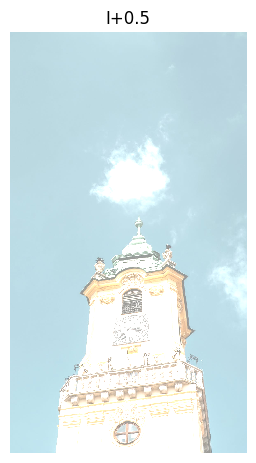

In [ ]:
### BEGIN SOLUTION
I_bright = np.clip(I+0.5, 0, 1)
io.imshow(I_bright, cmap = 'grey')
plt.axis("off")
plt.title("I+0.5");
### END SOLUTION

/tmp/ipython-input-381938896.py:7: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_dark, cmap = 'grey')


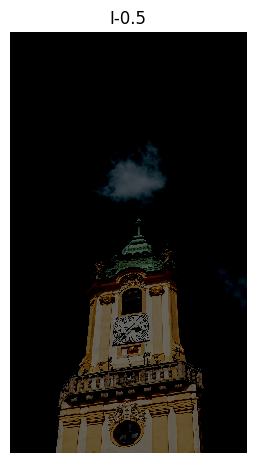

In [ ]:
# Decrease the brightness of the image without changing the contrast.
# Save the resulting image in I_dark and display it.
# I_dark = None

### BEGIN SOLUTION
I_dark = np.clip(I - 0.5, 0, 1)
io.imshow(I_dark, cmap = 'grey')
plt.axis("off")
plt.title("I-0.5");
### END SOLUTION

/tmp/ipython-input-298144422.py:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(I_tint)


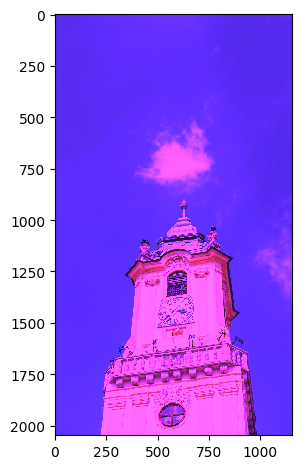

In [ ]:
### BEGIN SOLUTION
factor = [1.5, 0.5, 2.5]
I_tint = np.zeros(I.shape, dtype=np.float32)

for i in range(3):
    I_tint[:, :, i] = I[:, :, i] * factor[i]

I_tint = np.clip(I_tint, 0, 1)
io.imshow(I_tint)
### END SOLUTION

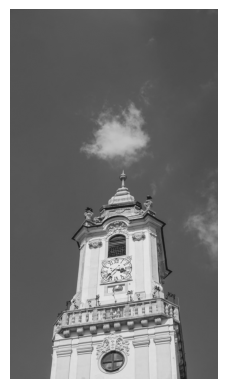

In [ ]:
# Convert the image into a grayscale image.
# Save it to I_gray and display it
# I_gray = None

### BEGIN SOLUTION
I_gray = color.rgb2gray(I)
plt.imshow(I_gray, cmap = 'gray')
plt.axis("off");
### END SOLUTION

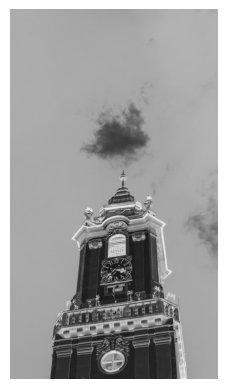

In [ ]:
# Display the negative of the grayscale image

### BEGIN SOLUTION
I_negative = 1 - I_gray
plt.imshow(I_negative, cmap = 'gray')
plt.axis("off");
### END SOLUTION

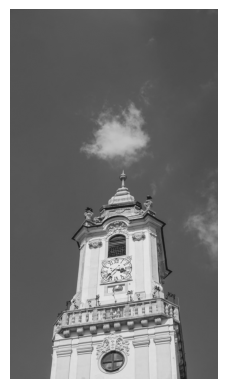

In [ ]:
### BEGIN SOLUTION
I_gray_norm = np.clip(I_gray, 0, 1)
I_degraded = 0.3 + (I_gray_norm*0.3)
plt.imshow(I_degraded, cmap = 'gray')
plt.axis("off");
### END SOLUTION

In [ ]:
def piecewise_contrast_stretch(I, r1, r2, s1, s2):

    # Write your code here
    I_stretched = np.zeros_like(I)

    # (0,0) - (r1, s1)
    alpha = (s1 - 0)/(r1 - 0)
    # (r1, s1) - (r2, s2)
    beta = (s2 - s1)/(r2 - r1)
    # (r2, s2) - (1, 1)
    gamma = (1 - s2)/(1 - r2)

    region1 = I<=r1
    I_stretched[region1] = alpha*I[region1]

    region2 = (I>r1) & (I<=r2)
    I_stretched[region2] = beta*(I[region2]-r1) + s1

    region3 = I>r2
    I_stretched[region3] = gamma*(I[region3]-r2) + s2

    return I_stretched
    ### BEGIN SOLUTION

    ### END SOLUTION



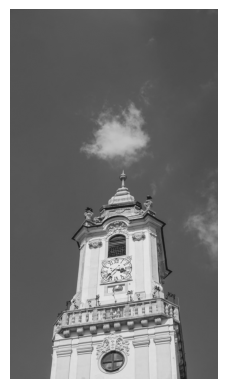

In [ ]:
r1 = 0.3
r2 = 0.6
s1 = 0.2
s2 = 0.8
I_stretched = piecewise_contrast_stretch(I_degraded, r1, r2, s1, s2)

# Display the strtched image

### BEGIN SOLUTION
plt.imshow(I_stretched, cmap = 'gray')
plt.axis("off");
### END SOLUTION

# Task 2 - Histogram and Equalization

Done by **22201633**

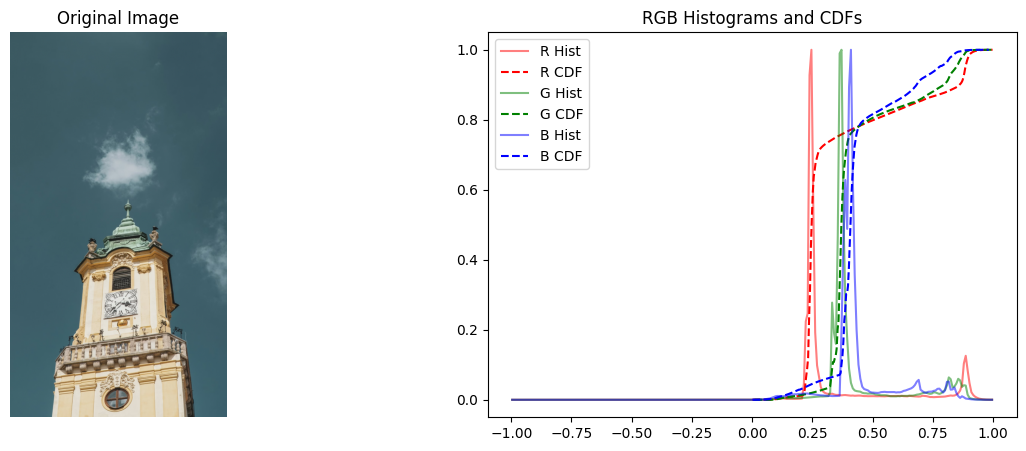

In [ ]:
### BEGIN SOLUTION
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(I)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
colors = ('r', 'g', 'b')

for i, color in enumerate(colors):
    hist, bins = exposure.histogram(I[:, :, i], source_range='dtype')
    img_cdf, bins_cdf = exposure.cumulative_distribution(I[:, :, i], nbins=256)
    plt.plot(bins, hist / hist.max(), color=color, alpha=0.5, label=f'{color.upper()} Hist')
    plt.plot(bins_cdf, img_cdf, color=color, linestyle='--', label=f'{color.upper()} CDF')

plt.title("RGB Histograms and CDFs")
plt.legend()
plt.show()
### END SOLUTION

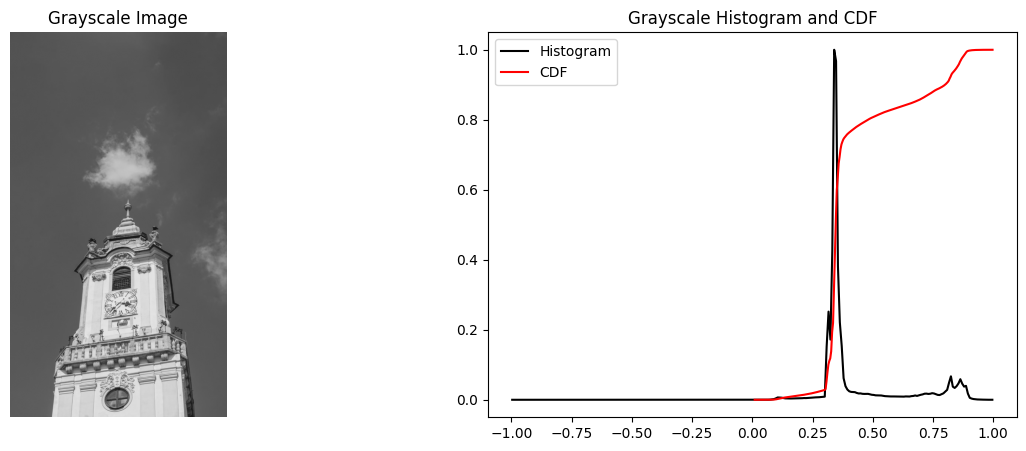

In [ ]:
### BEGIN SOLUTION
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(I_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.subplot(1, 2, 2)

hist, bins = exposure.histogram(I_gray, source_range='dtype')
img_cdf, bins_cdf = exposure.cumulative_distribution(I_gray, nbins=256)

plt.plot(bins, hist / hist.max(), 'k', label='Histogram')
plt.plot(bins_cdf, img_cdf, 'r', label='CDF')
plt.title("Grayscale Histogram and CDF")
plt.legend()
plt.show()
### END SOLUTION

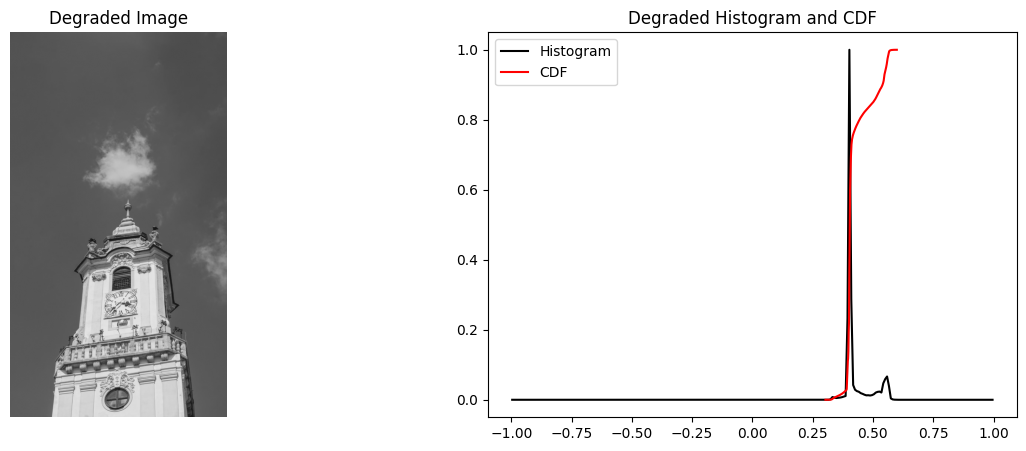

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(I_degraded, cmap='gray')
plt.title("Degraded Image")
plt.axis('off')
plt.subplot(1, 2, 2)

hist, bins = exposure.histogram(I_degraded, source_range='dtype')
img_cdf, bins_cdf = exposure.cumulative_distribution(I_degraded, nbins=256)

plt.plot(bins, hist / hist.max(), 'k', label='Histogram')
plt.plot(bins_cdf, img_cdf, 'r', label='CDF')

plt.title("Degraded Histogram and CDF")
plt.legend()
plt.show()
### END SOLUTION

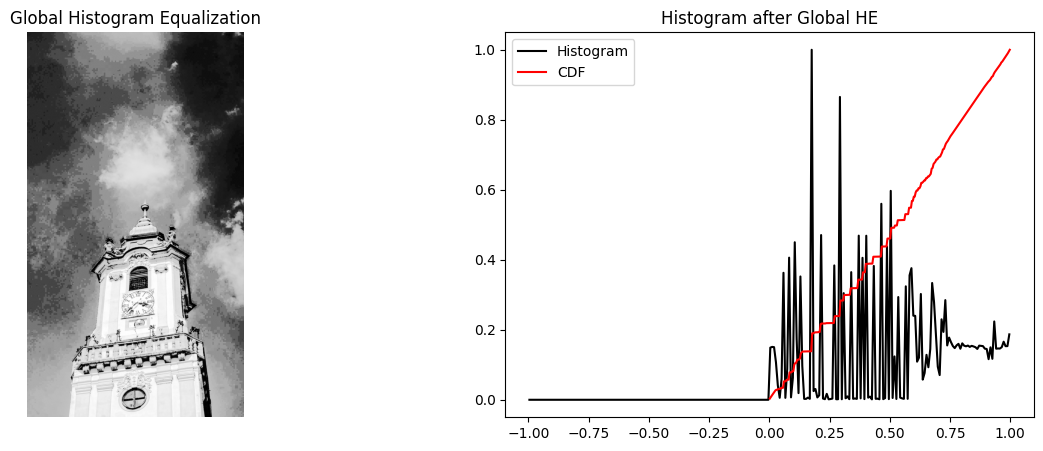

In [ ]:
I_recon_gray = exposure.equalize_hist(I_degraded)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(I_recon_gray, cmap='gray')
plt.title("Global Histogram Equalization")
plt.axis('off')
plt.subplot(1, 2, 2)
hist, bins = exposure.histogram(I_recon_gray, source_range='dtype')
img_cdf, bins_cdf = exposure.cumulative_distribution(I_recon_gray, nbins=256)

plt.plot(bins, hist / hist.max(), 'k', label='Histogram')
plt.plot(bins_cdf, img_cdf, 'r', label='CDF')
plt.title("Histogram after Global HE")
plt.legend()
plt.show()
### END SOLUTION

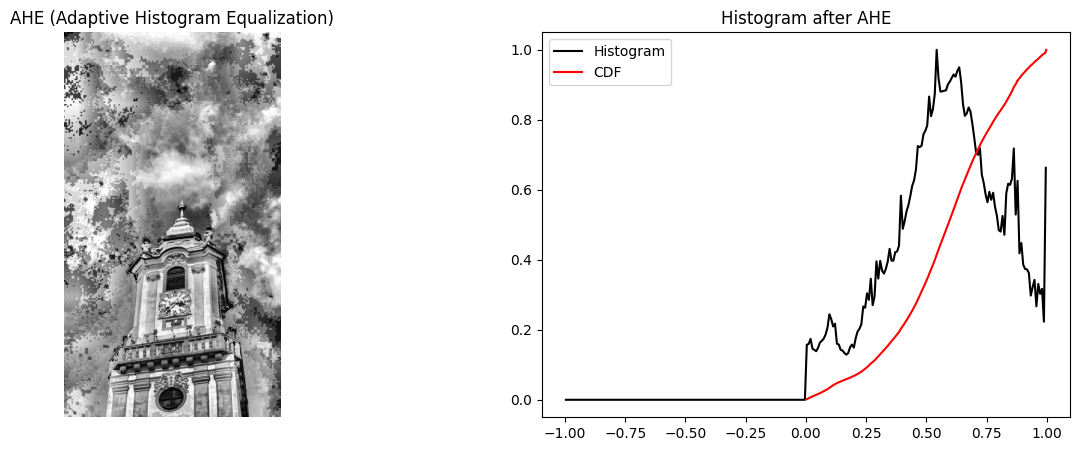

In [ ]:
I_recon_gray_2 = exposure.equalize_adapthist(I_degraded, clip_limit=1.0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(I_recon_gray_2, cmap='gray')
plt.title("AHE (Adaptive Histogram Equalization)")
plt.axis('off')
plt.subplot(1, 2, 2)
hist, bins = exposure.histogram(I_recon_gray_2, source_range='dtype')
img_cdf, bins_cdf = exposure.cumulative_distribution(I_recon_gray_2, nbins=256)

plt.plot(bins, hist / hist.max(), 'k', label='Histogram')
plt.plot(bins_cdf, img_cdf, 'r', label='CDF')
plt.title("Histogram after AHE")
plt.legend()
plt.show()
### END SOLUTION

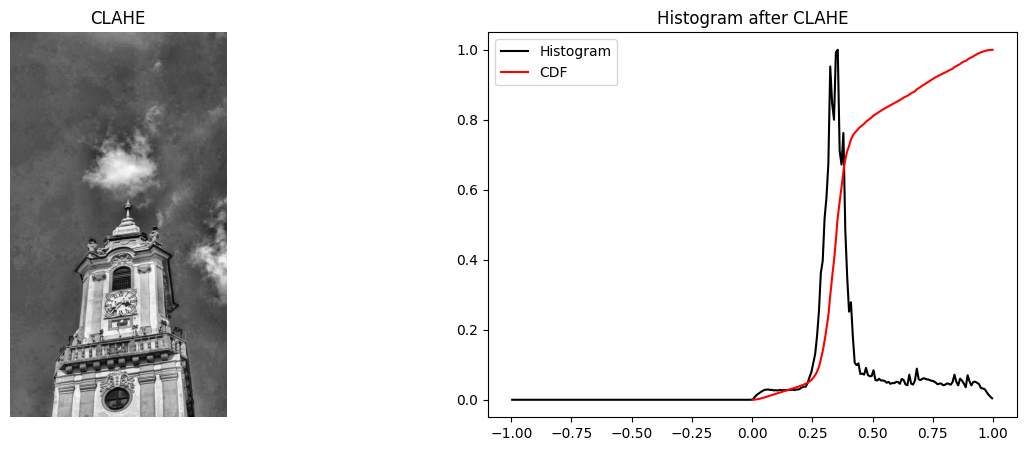

In [ ]:
I_recon_gray_3 = exposure.equalize_adapthist(I_degraded, clip_limit=0.03)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(I_recon_gray_3, cmap='gray')
plt.title("CLAHE")
plt.axis('off')
plt.subplot(1, 2, 2)
hist, bins = exposure.histogram(I_recon_gray_3, source_range='dtype')
img_cdf, bins_cdf = exposure.cumulative_distribution(I_recon_gray_3, nbins=256)

plt.plot(bins, hist / hist.max(), 'k', label='Histogram')
plt.plot(bins_cdf, img_cdf, 'r', label='CDF')
plt.title("Histogram after CLAHE")
plt.legend()
plt.show()
### END SOLUTION

In [ ]:
from skimage import color,exposure

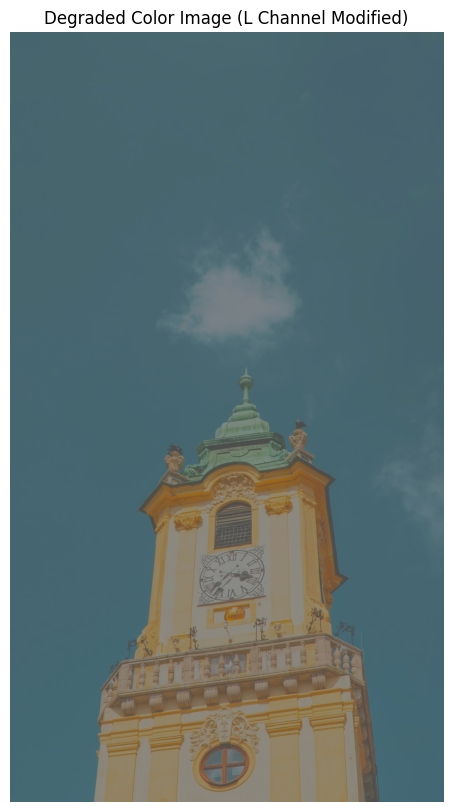

In [ ]:
I_rgb_degraded = None
I_lab = color.rgb2lab(I)
L = I_lab[:, :, 0]
L_norm = L / 100.0

L_degraded_norm = 0.3 + (L_norm * 0.3)
I_lab[:, :, 0] = L_degraded_norm * 100.0
I_rgb_degraded = color.lab2rgb(I_lab)

plt.figure(figsize=(10, 10))
plt.imshow(I_rgb_degraded)
plt.title("Degraded Color Image (L Channel Modified)")
plt.axis('off')
plt.show()
### END SOLUTION

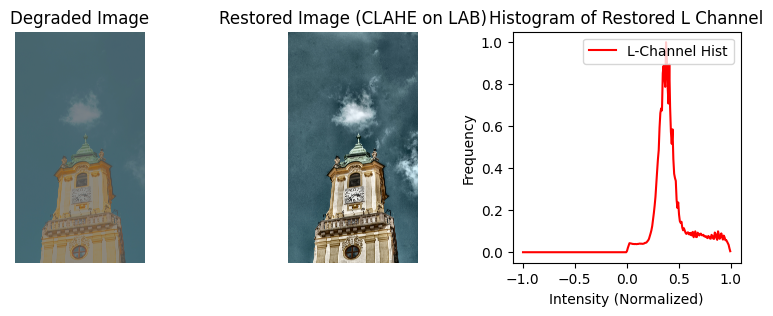

In [ ]:
I_recon_color = None
I_lab_deg = color.rgb2lab(I_rgb_degraded)
L_deg = I_lab_deg[:, :, 0]
L_deg_norm = L_deg / 100.0

#apply CLAHE
L_eq = exposure.equalize_adapthist(L_deg_norm, clip_limit=0.03)

I_lab_deg[:, :, 0] = L_eq * 100.0
I_recon_color = color.lab2rgb(I_lab_deg)

plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.imshow(I_rgb_degraded)
plt.title("Degraded Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(I_recon_color)
plt.title("Restored Image (CLAHE on LAB)")
plt.axis('off')

plt.subplot(1, 3, 3)
hist, bins = exposure.histogram(L_eq, source_range='dtype')
plt.plot(bins, hist / hist.max(), 'r', label='L-Channel Hist')
plt.title("Histogram of Restored L Channel")
plt.xlabel("Intensity (Normalized)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
### END SOLUTION

# Task 3 - Open Ended

 ### link:  https://drive.google.com/drive/folders/17gJVozfyj7cGzLvjLfzmc_ii1qYj-ZeU?usp=sharing

Dark: 0.0, 0.45098039215686275
Foggy: 0.6980392156862745, 1.0
Barcode: 0.0, 0.14509803921568626

After contrast stretching:
Dark: 0.000 - 1.000
Foggy: 0.000 - 1.000
Barcode: 0.000 - 1.000


/usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


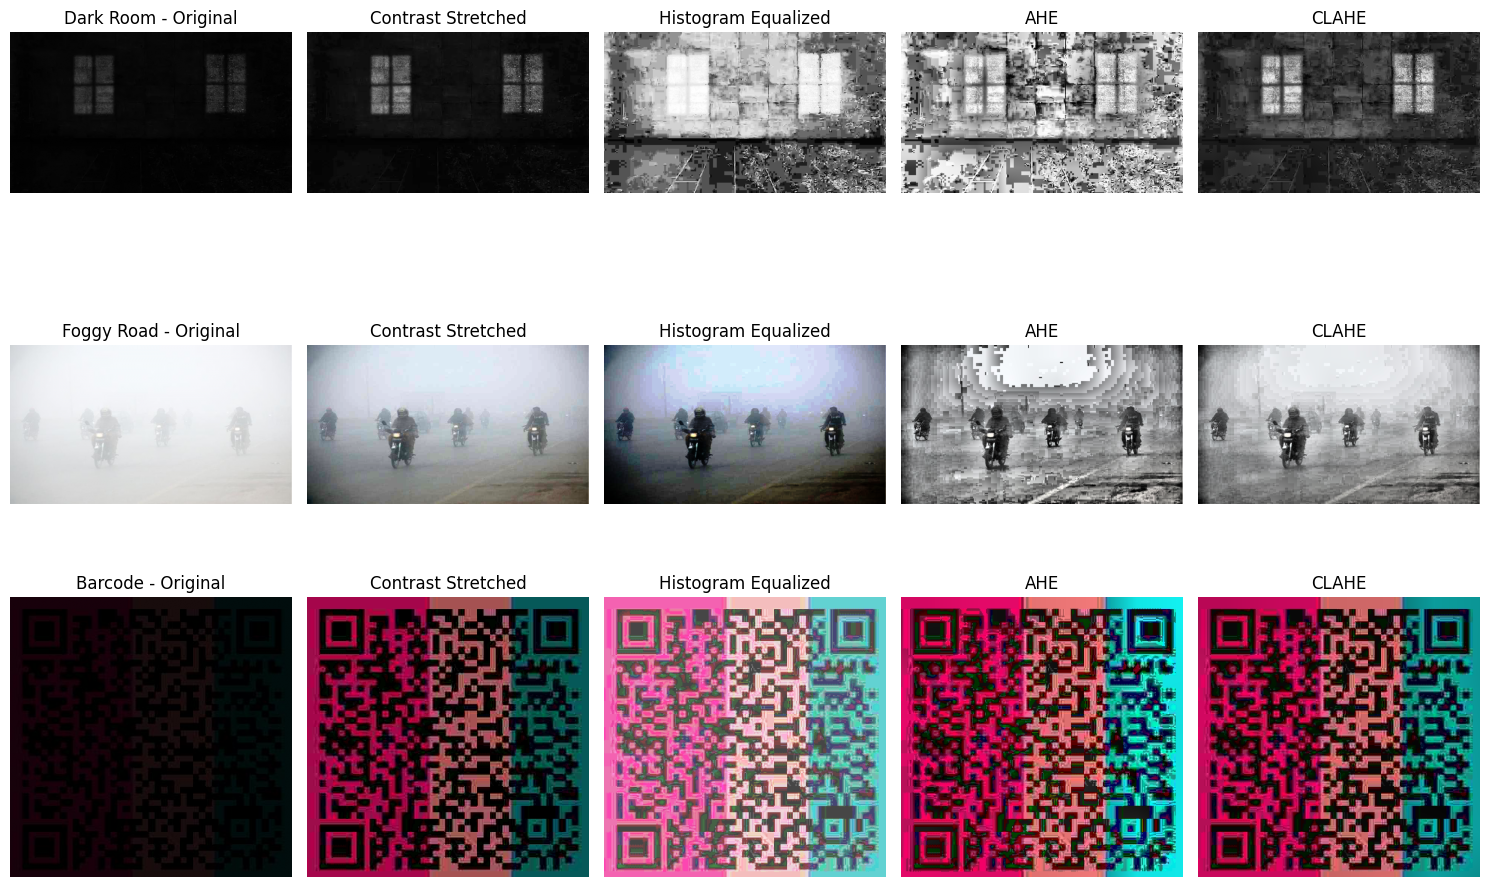

In [ ]:
### BEGIN SOLUTION
#Done by 24241162
Image1 = io.imread("/content/Dark_Room.jpg")
Image2 = io.imread("/content/Foggy_Road.jpg")
Image3 = io.imread("/content/Read_the_code.jpg")

dark = ski.img_as_float(Image1)
foggy = ski.img_as_float(Image2)
barcode = ski.img_as_float(Image3)

print(f"Dark: {dark.min()}, {dark.max()}")
print(f"Foggy: {foggy.min()}, {foggy.max()}")
print(f"Barcode: {barcode.min()}, {barcode.max()}")


dark_stretched = exposure.rescale_intensity(dark)
foggy_stretched = exposure.rescale_intensity(foggy)
barcode_stretched = exposure.rescale_intensity(barcode)

print("\nAfter contrast stretching:")
print(f"Dark: {dark_stretched.min():.3f} - {dark_stretched.max():.3f}")
print(f"Foggy: {foggy_stretched.min():.3f} - {foggy_stretched.max():.3f}")
print(f"Barcode: {barcode_stretched.min():.3f} - {barcode_stretched.max():.3f}")

dark_equalized = exposure.equalize_hist(dark)
foggy_equalized = exposure.equalize_hist(foggy)
barcode_equalized = exposure.equalize_hist(barcode)

dark_ahe = exposure.equalize_adapthist(dark, kernel_size=(64,64), clip_limit=0)
foggy_ahe = exposure.equalize_adapthist(foggy, kernel_size=(64,64), clip_limit=0)
barcode_ahe = exposure.equalize_adapthist(barcode, kernel_size=(64,64), clip_limit=0)

dark_clahe = exposure.equalize_adapthist(dark, kernel_size=(64,64), clip_limit=0.05)
foggy_clahe = exposure.equalize_adapthist(foggy, kernel_size=(64,64), clip_limit=0.05)
barcode_clahe = exposure.equalize_adapthist(barcode, kernel_size=(64,64), clip_limit=0.05)

fig, axes = plt.subplots(3, 5, figsize=(15, 10))

images_list = [dark, foggy, barcode]
images_stretched = [dark_stretched, foggy_stretched, barcode_stretched]
images_equalized = [dark_equalized, foggy_equalized, barcode_equalized]
images_ahe = [dark_ahe, foggy_ahe, barcode_ahe]
images_clahe = [dark_clahe, foggy_clahe, barcode_clahe]
names = ["Dark Room", "Foggy Road", "Barcode"]

for i in range(len(images_list)):

    axes[i, 0].imshow(images_list[i])
    axes[i, 0].set_title(f'{names[i]} - Original')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(images_stretched[i])
    axes[i, 1].set_title('Contrast Stretched')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(images_equalized[i])
    axes[i, 2].set_title('Histogram Equalized')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(images_ahe[i])
    axes[i, 3].set_title('AHE')
    axes[i, 3].axis('off')

    axes[i, 4].imshow(images_clahe[i])
    axes[i, 4].set_title('CLAHE')
    axes[i, 4].axis('off')


plt.tight_layout()
plt.show()



### END SOLUTION

### Your answers:

1.   For the *Dark room* image the walls are greyish in color
2.   For the *Foggy road* image there are about 8-9 vehicles
3.   For the scanable *Read the code* image there is a doc file that contains [practice problems](https://docs.google.com/document/d/1Y3Z_DvDcCJG9a0C4N4CMfX4KM5wGP-cxBekb8WT2cfg/edit?tab=t.0#heading=h.o4v8uit6s38p).

After processing the *Dark Room and the Read the code* images we can clearly see that CLAHE tends to give the best result among all the types of processing. Though for the foggy image the Histogram Equalized image tends to give a slightly more vibrant image. Even though CLAHE clears out the darker regions due to its light, contrast redistribution feature. We can still see more information in the *Histogram Equalized processed Foggy image* which allows us to see more vehicles in the background.

